# HGT: все признаки vs все признаки кроме одного

Этот ноутбук запускает ablation-эксперимент для оценки вклада признаков внутри полной HGT-модели.

Логика эксперимента:

1. Сначала обучается модель со всеми контекстными признаками.
2. Затем обучаются модели, где из полного набора по очереди удаляется один признак.
3. Сравнение выполняется только по `Recall@20` и `NDCG@20`.

Важно: `hgt_common.py` здесь используется как библиотека. Он ничего не знает про `all_except_*`. Эксперимент сам формирует строки `stage`, а общий код просто читает, какие названия признаков есть внутри строки.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))

from hgt_common import (
    HGTExperimentConfig,
    load_hgt_tables,
    make_hgt_runner,
    log_step,
    set_seed,
)


/Users/alexandro/DataspellProjects/recommend-system/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Настройки запуска

Поменяй `DATA_DIR`, если CSV-файлы лежат не рядом с ноутбуком.

In [2]:
DATA_DIR = Path("..")
OUTPUT_DIR = Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Можно расширить списки, если нужно прогнать сетку параметров.
THRESHOLD_VALUES = [5.0]
MIN_POS_VALUES = [5]

config = HGTExperimentConfig(
    threshold_values=THRESHOLD_VALUES,
    min_pos_values=MIN_POS_VALUES,
    k_values=[20],
    target_metrics=["recall", "ndcg"],
    epochs=100,
    batch_size=4096,
)

set_seed(config.seed)
log_step(f"device={config.device}")

[19:58:01] device=cpu


## 2. Формирование stage внутри experiment-файла

`hgt_common.py` не адаптируется под этот эксперимент. Он получает строку `stage` и включает те признаки, чьи названия встретил в строке.

In [3]:
CONTEXT_FEATURES = [
    "genres",
    "directors",
    "actors",
    "countries"
]

FEATURE_RU = {
    "genres": "Жанры",
    "directors": "Режиссёры",
    "actors": "Актёры",
    "countries": "Страны"
}


def make_stage(features):
    """Формирует строку stage для hgt_common.py.

    hgt_common.py сам проверит наличие подстрок:
    genres, directors, actors, countries, tags, age_group, occupation.
    """
    features = list(features)
    if not features:
        return "raw"
    return "_".join(features)


FULL_STAGE = make_stage(CONTEXT_FEATURES)

stage_plan = [
    {
        "experiment_stage": "all_context",
        "stage": FULL_STAGE,
        "removed_feature": None,
        "removed_feature_ru": "Ничего не удалено",
        "feature_set": ", ".join(CONTEXT_FEATURES),
    }
]

for removed_feature in CONTEXT_FEATURES:
    remaining_features = [feature for feature in CONTEXT_FEATURES if feature != removed_feature]
    stage_plan.append(
        {
            "experiment_stage": f"without_{removed_feature}",
            "stage": make_stage(remaining_features),
            "removed_feature": removed_feature,
            "removed_feature_ru": FEATURE_RU[removed_feature],
            "feature_set": ", ".join(remaining_features),
        }
    )

stage_plan_df = pd.DataFrame(stage_plan)
stage_plan_df

,experiment_stage,stage,removed_feature,removed_feature_ru,feature_set
0,all_context,genres_directors_actors_countries,NaN,Ничего не удалено,"genres, directors, actors, countries"
1,without_genres,directors_actors_countries,genres,Жанры,"directors, actors, countries"
2,without_directors,genres_actors_countries,directors,Режиссёры,"genres, actors, countries"
3,without_actors,genres_directors_countries,actors,Актёры,"genres, directors, countries"
4,without_countries,genres_directors_actors,countries,Страны,"genres, directors, actors"


## 3. Загрузка данных и создание runner

In [4]:
tables = load_hgt_tables(DATA_DIR)
runner = make_hgt_runner(tables, config)

[19:58:01] loaded rates: (948367, 4)
[19:58:01] loaded users: (6040, 4)
[19:58:01] loaded movies: (3433, 7)
[19:58:01] loaded movie_genres: (6408, 2)
[19:58:01] loaded movie_actors: (10285, 2)
[19:58:01] loaded movie_directors: (3676, 2)
[19:58:01] loaded movie_countries: (4765, 2)
[19:58:01] loaded movie_tags: (450912, 2)


## 4. Запуск экспериментов

На каждом этапе в логах будет видно: какой stage запущен, какой threshold/min_pos используется, когда строится граф, когда начинается обучение и evaluation.

In [5]:
all_results = []

total_runs = len(THRESHOLD_VALUES) * len(MIN_POS_VALUES) * len(stage_plan)
run_id = 0

for threshold in THRESHOLD_VALUES:
    for min_pos in MIN_POS_VALUES:
        for stage_cfg in stage_plan:
            run_id += 1
            experiment_stage = stage_cfg["experiment_stage"]
            stage = stage_cfg["stage"]
            removed_feature = stage_cfg["removed_feature"]
            removed_feature_ru = stage_cfg["removed_feature_ru"]
            feature_set = stage_cfg["feature_set"]

            print("\n" + "=" * 100)
            log_step(
                f"[{run_id}/{total_runs}] experiment_stage={experiment_stage}; "
                f"stage='{stage}'; threshold={threshold}; min_pos={min_pos}; "
                f"removed_feature={removed_feature}"
            )
            print("=" * 100)

            result_df, _ = runner.run_temporal_80_20(
                stage=stage,
                threshold=threshold,
                min_pos=min_pos,
                k_values=config.k_values,
            )

            result_df["experiment_stage"] = experiment_stage
            result_df["stage_string"] = stage
            result_df["removed_feature"] = removed_feature
            result_df["removed_feature_ru"] = removed_feature_ru
            result_df["feature_set"] = feature_set
            result_df["threshold"] = threshold
            result_df["min_pos"] = min_pos
            all_results.append(result_df)

results_df = pd.concat(all_results, ignore_index=True)

results_path = OUTPUT_DIR / "hgt_all_vs_without_one_recall20_ndcg20_results.csv"
results_df.to_csv(results_path, index=False)
log_step(f"saved results -> {results_path}")

results_df




[19:58:01] [1/5] experiment_stage=all_context; stage='genres_directors_actors_countries'; threshold=5.0; min_pos=5; removed_feature=None
[19:58:01] stage=genres_directors_actors_countries: preparing temporal 80/20 split; threshold=5.0, min_pos=5
[19:58:02] stage=genres_directors_actors_countries: positive stats
users_total    5614.0
min               5.0
p25              13.0
median           24.0
p75              48.0
max             533.0
users_lt5         0.0
users_lt10      868.0
users_lt20     2332.0
dtype: float64
[19:58:02] stage=genres_directors_actors_countries: train/test shapes: train=(168107, 3), test=(44791, 3)
[19:58:02] stage=genres_directors_actors_countries: fit started; k_values=[20]; target_metrics=['recall', 'ndcg']
[19:58:02] stage=genres_directors_actors_countries: building index maps
[19:58:02] context: filtering context tables by train movies
[19:58:02] context sizes after filtering: genres=4908, directors=1747, actors=3675, countries=3952, tags=209972
[19:58:0

,stage,k,n_users_eval,recall,ndcg,experiment_stage,stage_string,removed_feature,removed_feature_ru,feature_set,threshold,min_pos
0,genres_directors_actors_countries,20,5614,0.151828,0.099770,all_context,genres_directors_actors_countries,None,Ничего не удалено,"genres, directors, actors, countries",5.0,5
1,directors_actors_countries,20,5614,0.149191,0.099729,without_genres,directors_actors_countries,genres,Жанры,"directors, actors, countries",5.0,5
2,genres_actors_countries,20,5614,0.150300,0.100694,without_directors,genres_actors_countries,directors,Режиссёры,"genres, actors, countries",5.0,5
3,genres_directors_countries,20,5614,0.143421,0.096189,without_actors,genres_directors_countries,actors,Актёры,"genres, directors, countries",5.0,5
4,genres_directors_actors,20,5614,0.151612,0.101680,without_countries,genres_directors_actors,countries,Страны,"genres, directors, actors",5.0,5


## 5. Расчёт изменения относительно полной модели

Для интерпретации удобны две величины:

- `delta_vs_all_context = without_one - all_context`. Если значение отрицательное, удаление признака ухудшило качество.
- `removed_feature_contribution = all_context - without_one`. Если значение положительное, удалённый признак был полезен в полной модели.

In [6]:
metric_cols = ["recall", "ndcg"]
key_cols = ["threshold", "min_pos", "k"]

baseline_df = (
    results_df[results_df["experiment_stage"] == "all_context"]
    [key_cols + metric_cols]
    .rename(columns={metric: f"{metric}_all_context" for metric in metric_cols})
)

ablation_df = results_df[results_df["experiment_stage"] != "all_context"].copy()
comparison_df = ablation_df.merge(baseline_df, on=key_cols, how="left")

for metric in metric_cols:
    comparison_df[f"{metric}_delta_vs_all_context"] = (
        comparison_df[metric] - comparison_df[f"{metric}_all_context"]
    )
    comparison_df[f"{metric}_removed_feature_contribution"] = (
        comparison_df[f"{metric}_all_context"] - comparison_df[metric]
    )

comparison_path = OUTPUT_DIR / "hgt_all_vs_without_one_recall20_ndcg20_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
log_step(f"saved comparison -> {comparison_path}")

comparison_df

[00:02:24] saved comparison -> hgt_all_vs_without_one_recall20_ndcg20_comparison.csv


,stage,k,n_users_eval,recall,ndcg,experiment_stage,stage_string,removed_feature,removed_feature_ru,feature_set,threshold,min_pos,recall_all_context,ndcg_all_context,recall_delta_vs_all_context,recall_removed_feature_contribution,ndcg_delta_vs_all_context,ndcg_removed_feature_contribution
0,directors_actors_countries,20,5614,0.149191,0.099729,without_genres,directors_actors_countries,genres,Жанры,"directors, actors, countries",5.0,5,0.151828,0.09977,-0.002637,0.002637,-0.000041,0.000041
1,genres_actors_countries,20,5614,0.150300,0.100694,without_directors,genres_actors_countries,directors,Режиссёры,"genres, actors, countries",5.0,5,0.151828,0.09977,-0.001528,0.001528,0.000924,-0.000924
2,genres_directors_countries,20,5614,0.143421,0.096189,without_actors,genres_directors_countries,actors,Актёры,"genres, directors, countries",5.0,5,0.151828,0.09977,-0.008407,0.008407,-0.003581,0.003581
3,genres_directors_actors,20,5614,0.151612,0.101680,without_countries,genres_directors_actors,countries,Страны,"genres, directors, actors",5.0,5,0.151828,0.09977,-0.000216,0.000216,0.001910,-0.001910


## 6. Длинная таблица для графиков и текста ВКР

In [7]:
long_rows = []
for _, row in comparison_df.iterrows():
    for metric in metric_cols:
        long_rows.append({
            "threshold": row["threshold"],
            "min_pos": row["min_pos"],
            "k": row["k"],
            "metric": metric,
            "removed_feature": row["removed_feature"],
            "removed_feature_ru": row["removed_feature_ru"],
            "all_context_value": row[f"{metric}_all_context"],
            "without_feature_value": row[metric],
            "delta_vs_all_context": row[f"{metric}_delta_vs_all_context"],
            "removed_feature_contribution": row[f"{metric}_removed_feature_contribution"],
        })

comparison_long_df = pd.DataFrame(long_rows)
long_path = OUTPUT_DIR / "hgt_all_vs_without_one_recall20_ndcg20_deltas_long.csv"
comparison_long_df.to_csv(long_path, index=False)
log_step(f"saved long deltas -> {long_path}")

comparison_long_df

[00:02:25] saved long deltas -> hgt_all_vs_without_one_recall20_ndcg20_deltas_long.csv


,threshold,min_pos,k,metric,removed_feature,removed_feature_ru,all_context_value,without_feature_value,delta_vs_all_context,removed_feature_contribution
0,5.0,5,20,recall,genres,Жанры,0.151828,0.149191,-0.002637,0.002637
1,5.0,5,20,ndcg,genres,Жанры,0.099770,0.099729,-0.000041,0.000041
2,5.0,5,20,recall,directors,Режиссёры,0.151828,0.150300,-0.001528,0.001528
3,5.0,5,20,ndcg,directors,Режиссёры,0.099770,0.100694,0.000924,-0.000924
4,5.0,5,20,recall,actors,Актёры,0.151828,0.143421,-0.008407,0.008407
5,5.0,5,20,ndcg,actors,Актёры,0.099770,0.096189,-0.003581,0.003581
6,5.0,5,20,recall,countries,Страны,0.151828,0.151612,-0.000216,0.000216
7,5.0,5,20,ndcg,countries,Страны,0.099770,0.101680,0.001910,-0.001910


## 7. Графики вклада признаков

Положительное значение `removed_feature_contribution` означает, что удаление признака ухудшило качество, следовательно признак был полезен внутри полной модели.

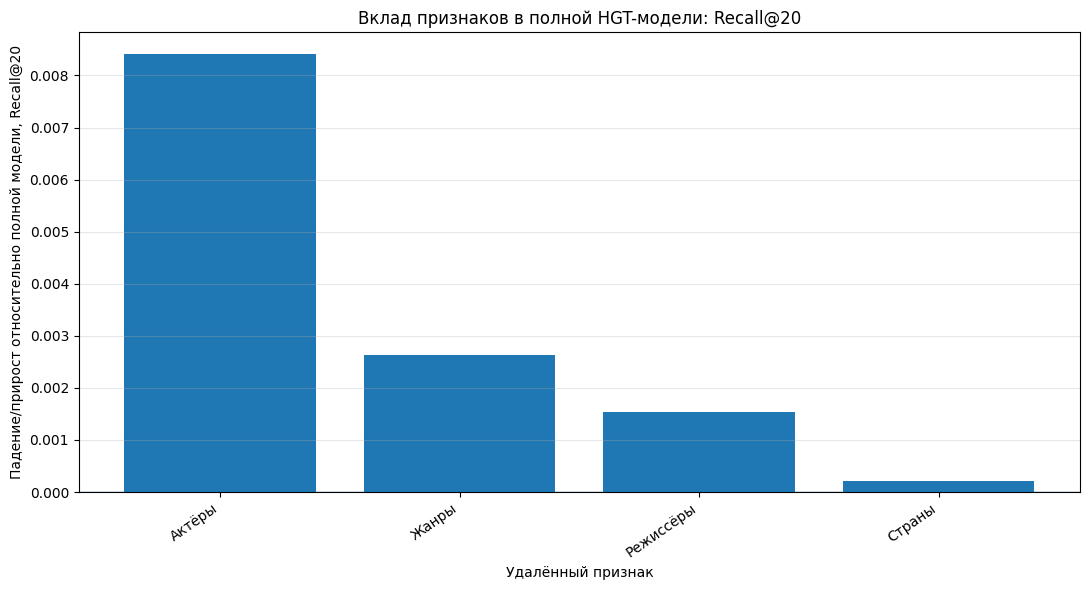

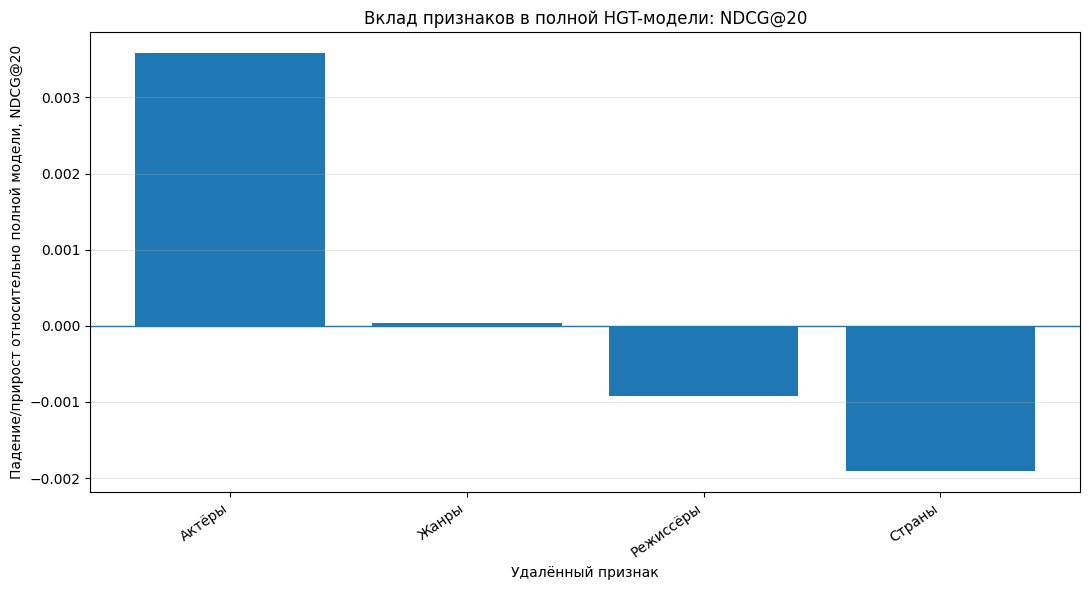

In [8]:
def plot_removed_feature_contribution(metric: str, threshold: float, min_pos: int, k: int = 20):
    plot_df = comparison_long_df[
        (comparison_long_df["metric"] == metric) &
        (comparison_long_df["threshold"] == threshold) &
        (comparison_long_df["min_pos"] == min_pos) &
        (comparison_long_df["k"] == k)
    ].copy()

    plot_df = plot_df.sort_values("removed_feature_contribution", ascending=False)

    plt.figure(figsize=(11, 6))
    plt.bar(plot_df["removed_feature_ru"], plot_df["removed_feature_contribution"])
    plt.axhline(0, linewidth=1)
    metric_title = "Recall@20" if metric == "recall" else "NDCG@20"
    plt.title(f"Вклад признаков в полной HGT-модели: {metric_title}")
    plt.xlabel("Удалённый признак")
    plt.ylabel(f"Падение/прирост относительно полной модели, {metric_title}")
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


for metric in ["recall", "ndcg"]:
    plot_removed_feature_contribution(
        metric=metric,
        threshold=THRESHOLD_VALUES[0],
        min_pos=MIN_POS_VALUES[0],
        k=20,
    )

## 8. Графики абсолютных значений без одного признака

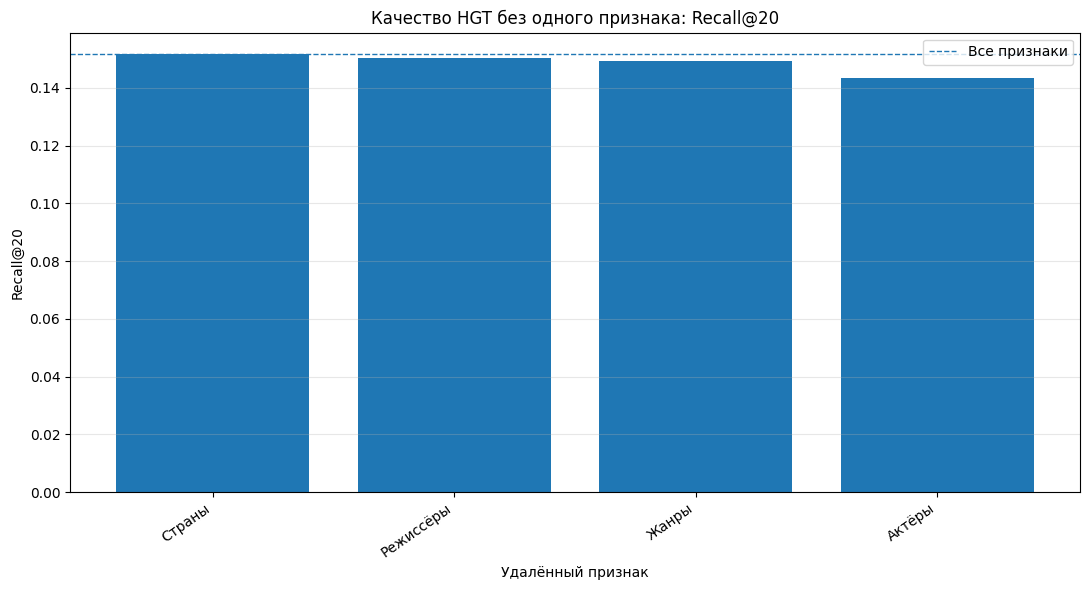

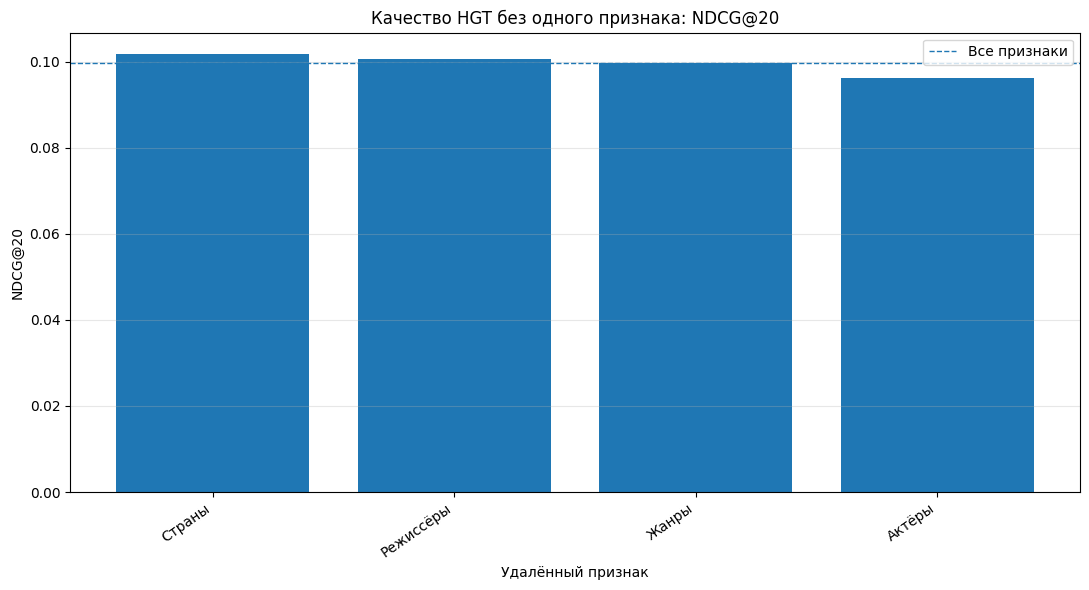

In [9]:
def plot_without_feature_absolute(metric: str, threshold: float, min_pos: int, k: int = 20):
    plot_df = comparison_long_df[
        (comparison_long_df["metric"] == metric) &
        (comparison_long_df["threshold"] == threshold) &
        (comparison_long_df["min_pos"] == min_pos) &
        (comparison_long_df["k"] == k)
    ].copy()

    baseline_value = plot_df["all_context_value"].iloc[0]
    plot_df = plot_df.sort_values("without_feature_value", ascending=False)

    plt.figure(figsize=(11, 6))
    plt.bar(plot_df["removed_feature_ru"], plot_df["without_feature_value"])
    plt.axhline(baseline_value, linewidth=1, linestyle="--", label="Все признаки")
    metric_title = "Recall@20" if metric == "recall" else "NDCG@20"
    plt.title(f"Качество HGT без одного признака: {metric_title}")
    plt.xlabel("Удалённый признак")
    plt.ylabel(metric_title)
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for metric in ["recall", "ndcg"]:
    plot_without_feature_absolute(
        metric=metric,
        threshold=THRESHOLD_VALUES[0],
        min_pos=MIN_POS_VALUES[0],
        k=20,
    )

## 9. Краткая интерпретационная таблица

In [10]:
summary_df = comparison_long_df.pivot_table(
    index=["removed_feature", "removed_feature_ru"],
    columns="metric",
    values="removed_feature_contribution",
    aggfunc="mean",
).reset_index()

summary_df = summary_df.rename(columns={
    "recall": "Средний вклад по Recall@20",
    "ndcg": "Средний вклад по NDCG@20",
})

summary_df = summary_df.sort_values("Средний вклад по Recall@20", ascending=False)
summary_df

metric,removed_feature,removed_feature_ru,Средний вклад по NDCG@20,Средний вклад по Recall@20
0,actors,Актёры,0.003581,0.008407
3,genres,Жанры,0.000041,0.002637
2,directors,Режиссёры,-0.000924,0.001528
1,countries,Страны,-0.001910,0.000216


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = results_df
deltas_df = comparison_long_df
comparison_df = comparison_df

# ===== Порядок признаков =====
feature_order = ["genres", "directors", "actors", "countries"]

# ===== Русские подписи =====
feature_labels = {
    "genres": "Жанры",
    "directors": "Режиссёры",
    "actors": "Актёры",
    "countries": "Страны",
}

# ===== Подготовка comparison_df =====
comparison_df["removed_feature"] = pd.Categorical(
    comparison_df["removed_feature"],
    categories=feature_order,
    ordered=True
)
comparison_df = comparison_df.sort_values("removed_feature")
comparison_df["feature_label"] = comparison_df["removed_feature"].map(feature_labels)

# ===== Базовые значения all_context =====
all_context_recall = comparison_df["recall_all_context"].iloc[0]
all_context_ndcg = comparison_df["ndcg_all_context"].iloc[0]

# ===== Подготовка deltas_df =====
deltas_df["removed_feature"] = pd.Categorical(
    deltas_df["removed_feature"],
    categories=feature_order,
    ordered=True
)
deltas_df = deltas_df.sort_values(["metric", "removed_feature"])
deltas_df["feature_label"] = deltas_df["removed_feature_ru"]

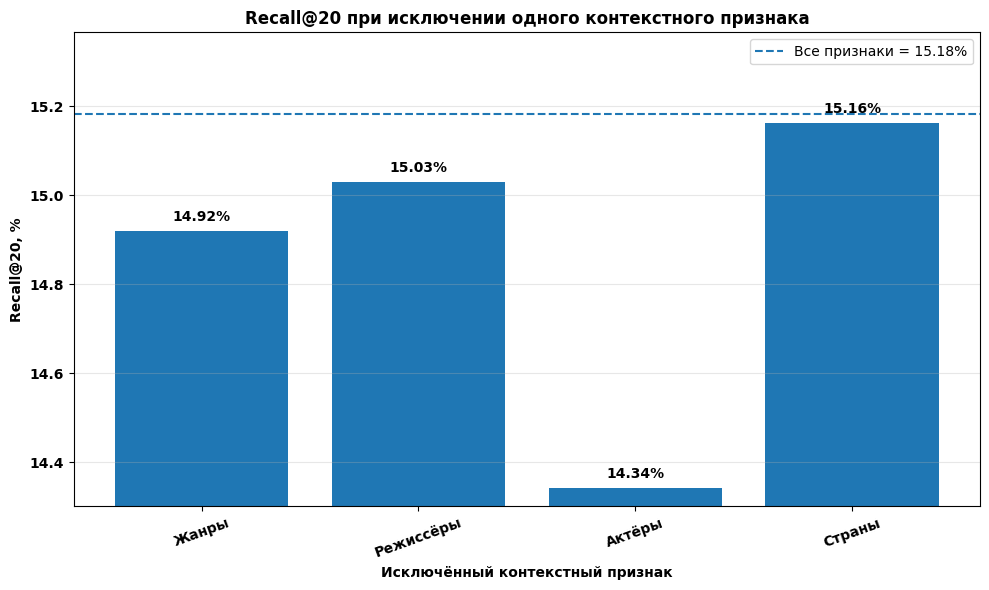

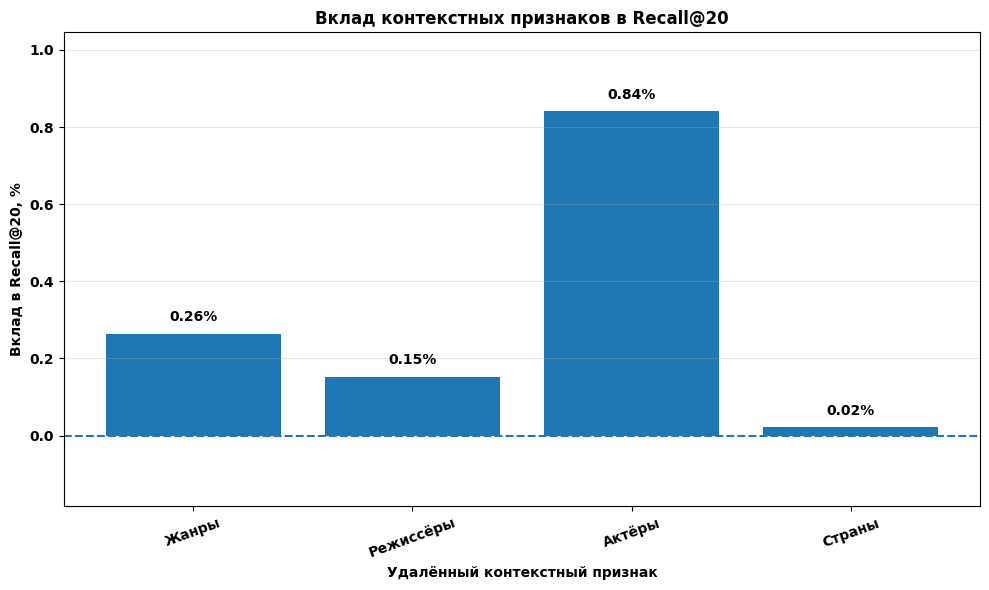

In [13]:
# ===== Recall@20: все признаки, кроме одного =====
plot_df = comparison_df.copy()
plot_df["recall_percent"] = plot_df["recall"] * 100
all_context_recall_percent = all_context_recall * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(plot_df["feature_label"], plot_df["recall_percent"])

plt.axhline(
    all_context_recall_percent,
    linestyle="--",
    linewidth=1.5,
    label=f"Все признаки = {all_context_recall_percent:.2f}%"
)

plt.title(
    "Recall@20 при исключении одного контекстного признака",
    fontweight="bold"
)
plt.xlabel("Исключённый контекстный признак", fontweight="bold")
plt.ylabel("Recall@20, %", fontweight="bold")

plt.xticks(rotation=20, fontweight="bold")
plt.yticks(fontweight="bold")

# Подписи значений
y_min = plot_df["recall_percent"].min()
y_max = plot_df["recall_percent"].max()
margin = (y_max - y_min) * 0.25 if y_max > y_min else 0.05
plt.ylim(y_min - margin * 0.2, y_max + margin)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + margin * 0.08,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===== Вклад удалённого признака в Recall@20 =====
recall_delta_df = deltas_df[deltas_df["metric"] == "recall"].copy()
recall_delta_df["contribution_percent"] = recall_delta_df["removed_feature_contribution"] * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(
    recall_delta_df["feature_label"],
    recall_delta_df["contribution_percent"]
)

plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title(
    "Вклад контекстных признаков в Recall@20",
    fontweight="bold"
)
plt.xlabel("Удалённый контекстный признак", fontweight="bold")
plt.ylabel("Вклад в Recall@20, %", fontweight="bold")

plt.xticks(rotation=20, fontweight="bold")
plt.yticks(fontweight="bold")

y_min = recall_delta_df["contribution_percent"].min()
y_max = recall_delta_df["contribution_percent"].max()
margin = (y_max - y_min) * 0.25 if y_max > y_min else 0.05
plt.ylim(y_min - margin, y_max + margin)

for bar in bars:
    value = bar.get_height()
    offset = margin * 0.12

    if value >= 0:
        y = value + offset
        va = "bottom"
    else:
        y = value - offset
        va = "top"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{value:.2f}%",
        ha="center",
        va=va,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

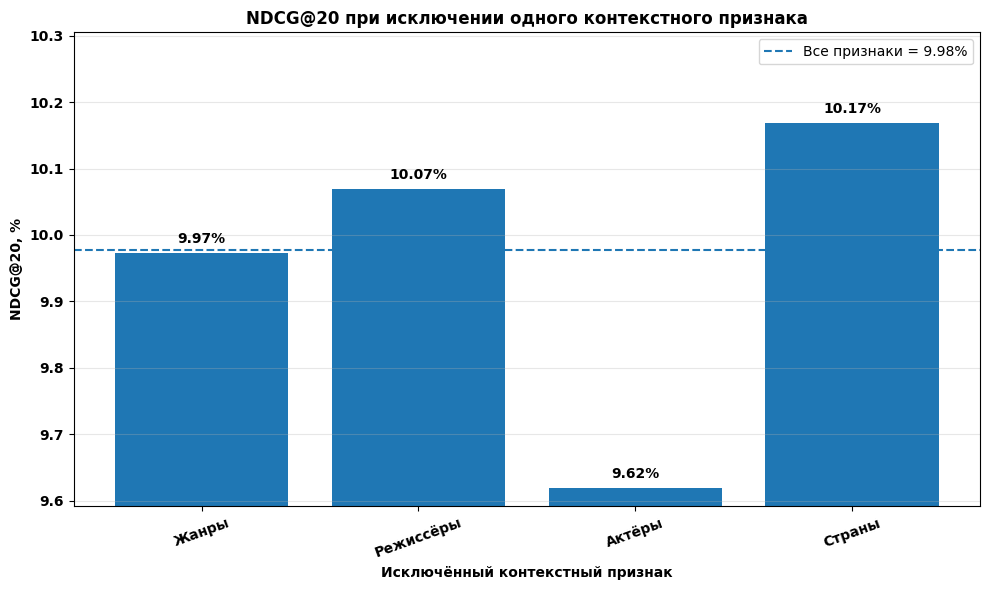

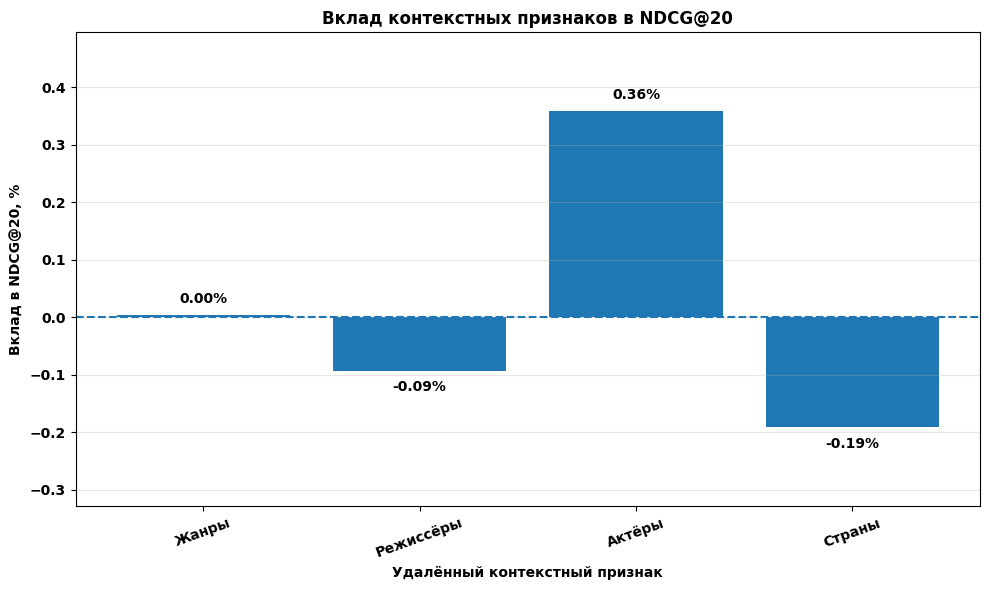

In [14]:
# ===== NDCG@20: все признаки, кроме одного =====
plot_df = comparison_df.copy()
plot_df["ndcg_percent"] = plot_df["ndcg"] * 100
all_context_ndcg_percent = all_context_ndcg * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(plot_df["feature_label"], plot_df["ndcg_percent"])

plt.axhline(
    all_context_ndcg_percent,
    linestyle="--",
    linewidth=1.5,
    label=f"Все признаки = {all_context_ndcg_percent:.2f}%"
)

plt.title(
    "NDCG@20 при исключении одного контекстного признака",
    fontweight="bold"
)
plt.xlabel("Исключённый контекстный признак", fontweight="bold")
plt.ylabel("NDCG@20, %", fontweight="bold")

plt.xticks(rotation=20, fontweight="bold")
plt.yticks(fontweight="bold")

y_min = plot_df["ndcg_percent"].min()
y_max = plot_df["ndcg_percent"].max()
margin = (y_max - y_min) * 0.25 if y_max > y_min else 0.05
plt.ylim(y_min - margin * 0.2, y_max + margin)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + margin * 0.08,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===== Вклад удалённого признака в NDCG@20 =====
ndcg_delta_df = deltas_df[deltas_df["metric"] == "ndcg"].copy()
ndcg_delta_df["contribution_percent"] = ndcg_delta_df["removed_feature_contribution"] * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(
    ndcg_delta_df["feature_label"],
    ndcg_delta_df["contribution_percent"]
)

plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title(
    "Вклад контекстных признаков в NDCG@20",
    fontweight="bold"
)
plt.xlabel("Удалённый контекстный признак", fontweight="bold")
plt.ylabel("Вклад в NDCG@20, %", fontweight="bold")

plt.xticks(rotation=20, fontweight="bold")
plt.yticks(fontweight="bold")

y_min = ndcg_delta_df["contribution_percent"].min()
y_max = ndcg_delta_df["contribution_percent"].max()
margin = (y_max - y_min) * 0.25 if y_max > y_min else 0.05
plt.ylim(y_min - margin, y_max + margin)

for bar in bars:
    value = bar.get_height()
    offset = margin * 0.12

    if value >= 0:
        y = value + offset
        va = "bottom"
    else:
        y = value - offset
        va = "top"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{value:.2f}%",
        ha="center",
        va=va,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()